# **week3/ day4**



## recap --> week 3/day-3

1. Write sigmoid function

2. Formula for cross-entropy loss — one line


3. TP, TN, FP, FN definitions for Titanic case
4. Precision vs Recall — one line each

In [2]:
#1. Write sigmoid function
import numpy as np

def sigmoid(z):
  g_z = 1 / (1 + np.exp(-z))
  return g_z

- 2. Formula for cross-entropy loss -> one line
             
      - (y_pred ^ y ) (1-y_pred) ^ (1- y)
  
              1. loss = -1/n * Σ [y * log(y_pred)  +  (1-y) * log(1-y_pred)]
              

 - 3. TP, TN, FP, FN definitions for Titanic case

  1. TP : Actually Survived and model predicted Survived(1).
  2. TN : Died and model predicted them as dead(0).
  3. FP : Died but model predicted them as survivors(1).
  4. FN : Survived but model predicted them as dead(0).

- 4. Precision vs Recall
1. Precision : TP / (TP + FP)
2. Recall : TP / (TP + FN)

# **week3/ day 4**



1. Plot ROC curve using roc_curve and RocCurveDisplay from sklearn
2. Print AUC score using roc_auc_score
3. Manually vary threshold from 0.3 to 0.7 — use clf.predict_proba() instead of clf.predict(), apply threshold manually, recalculate precision and recall each time
4. Plot precision vs recall as threshold changes — two lines on same plot
5. Questions:

        1. When would you use accuracy over F1?
        2. When would you use F1 over accuracy?
        3. When would you use AUC over both?

In [3]:
#Training LogisticRegression on Titanic (Sex, Pclass, Age, Fare)

import pandas as pd

df = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')

df.fillna({'Age': df['Age'].median()}, inplace=True)
df.dropna(subset=['Embarked'], inplace=True)
df['Title'] = df['Name'].str.extract(r', ([A-Za-z]+)\.')
df['AgeGroup'] = df['Age'].apply(lambda x: 'Child' if x<13 else 'Teen' if x<18 else 'Adult' if x<61 else 'Senior')
df['Sex_encoded'] = df['Sex'].map({'male':0, 'female':1})

In [4]:
features = ['Pclass', 'Age', 'Fare', 'Sex_encoded']
X = df[features]
y = df['Survived']


In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import  accuracy_score, precision_score,recall_score

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, random_state=42)

#fit logistic Regression
clf = LogisticRegression().fit(X_train,y_train)

#predict
y_pred = clf.predict(X_test)
print(f"Accuracy : {accuracy_score(y_test,y_pred):.2f}")



Accuracy : 0.80


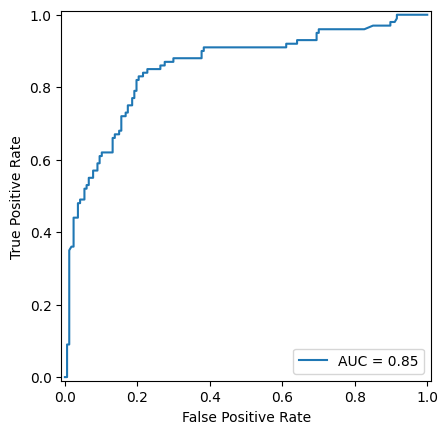

In [33]:
# 1. Plot ROC curve using roc_curve and RocCurveDisplay from sklearn
import matplotlib.pyplot as plt
from sklearn import metrics

#probability iof survival
y_proba = clf.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = metrics.roc_curve(y_test,y_proba)

roc_auc = metrics.auc(fpr,tpr)

display = metrics.RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc ) #, name = "Estmator")
display.plot()

plt.show()

In [13]:
# 2. Print AUC score using roc_auc_score
roc_auc

np.float64(0.792185628742515)

In [18]:
# 3. Manually vary threshold from 0.3 to 0.7 — use clf.predict_proba() instead of clf.predict(),
    #apply threshold manually, recalculate precision and recall each time


y_pred_proba = clf.predict_proba(X_test)
y_pred_proba.shape

(267, 2)

In [19]:
y_proba = clf.predict_proba(X_test)[:,1] #probability iof survival


y_pred_custom = (y_proba >= 0.35).astype(int) #own threshold

In [23]:
precision_ = precision_score(y_test, y_pred_custom)
precision_

0.68

In [26]:
recall_ = recall_score(y_test,y_pred_custom)
recall_

0.85

In [29]:
# vary threshold from 0.3 to 0.7
thresholds_vary = [0.3, 0.4, 0.5, 0.6, 0.7]
precision_list = []
recall_list = []
y_proba = clf.predict_proba(X_test)[:, 1]

for i in thresholds_vary:
  y_pred_custom_ = (y_proba >=i).astype(int)
  precision_ = precision_score(y_test, y_pred_custom_)
  recall_ = recall_score(y_test,y_pred_custom_)

  #append precision,recall for further plotting
  precision_list.append(precision_)
  recall_list.append(recall_)
  print(f" Threshold :{i}, Precision Score:{precision_ :.2f}, Recall Score: {recall_}")



 Threshold :0.3, Precision Score:0.65, Recall Score: 0.86
 Threshold :0.4, Precision Score:0.69, Recall Score: 0.84
 Threshold :0.5, Precision Score:0.71, Recall Score: 0.77
 Threshold :0.6, Precision Score:0.79, Recall Score: 0.59
 Threshold :0.7, Precision Score:0.85, Recall Score: 0.51


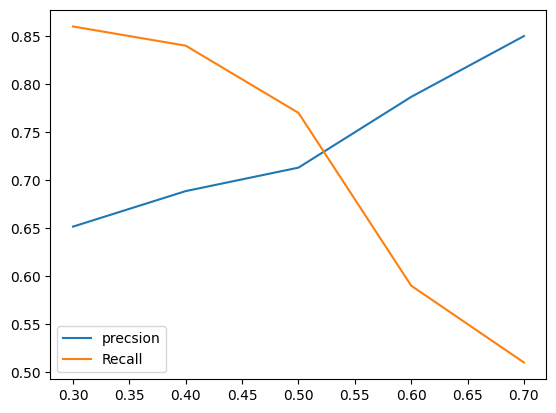

In [34]:
# 4. Plot precision vs recall as threshold changes — two lines on same plot
fig,ax = plt.subplots()
ax.plot(thresholds_vary,precision_list,label="precsion")
ax.plot(thresholds_vary,recall_list,label="Recall")
ax.legend()
plt.show()

5. Questions:

        1. When would you use accuracy over F1?
        2. When would you use F1 over accuracy?
        3. When would you use AUC over both?

1. When would you use accuracy over F1?
  - To judge overall success of model for y_pred.
  - When classes are balanced and all errors cost equally.
  - Example: classifying images of cats vs dogs with equal numbers of each.

2. When would you use F1 over accuracy?
  - To check individual correct rate for both predictions death/surviva(0/1)
  - When classes are imbalanced.
  - Example: fraud detection : 99% legitimate transactions means a model predicting "always legitimate" gets 99% accuracy but catches zero fraud. F1 penalises this.

3. When would you use AUC over both?
  - To judge TP v/s FP rate.
  - When you want to evaluate model performance independent of threshold.
  - Useful when you haven't decided the classification threshold yet, or when comparing multiple models fairly.